In [1]:
# Adapted from https://github.com/elstonlab/PhagocytosisRosetteModel/blob/main/WPGAP_FP_Check_EA_Results.ipynb by J. Cody Herron
import numpy as np
from scipy.integrate import odeint
import pickle
from math import sqrt
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

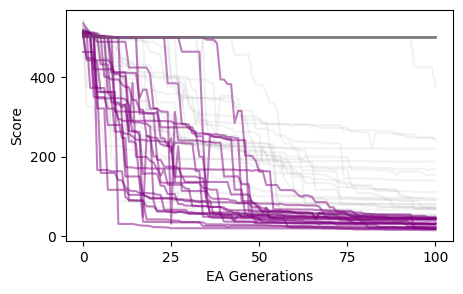

In [2]:
folder = os.getcwd()
file_loc = folder

threshold_good_score = 50 # Threshold for fitness function to be considered as a successful round of parameter searching
path, dirs, files = os.walk(file_loc).__next__()
len_files = 100 # Total number of rounds of parameter searching

runs_df = pd.DataFrame(index = range(len_files), columns=['Score','a_act', 'd_act', 'K_n', 'n', 'a_x', 'd_x', 'm',
                                                          'K_S', 'K_a', 'k1', 'k2', 'k3', 'k4', 'k5', 'XbsT', 'sT']) # Load optimized parameters
best_scores = []
best_inds = []
plt.figure(figsize=(5,3))
for i in range(len_files):
    pickled_file = os.path.join(folder, f"{i}.pickled")
    if os.path.exists(pickled_file):
        logbook = pickle.load( open( folder + '/' + str(i) + ".pickled", "rb" ) )
        runs_df.iloc[i] = np.insert(logbook[1][-1],0,logbook[0][-1])
            
        best_scores.append(logbook[0][-1])
        best_inds.append(logbook[1][-1])
      
        run = np.array(logbook[0])
        score = logbook[0][-1]
        if score < threshold_good_score:
            plt.plot(run,color='purple',alpha=.5)  
        else:
            plt.plot(run,color='gray',alpha=0.1)

plt.xlabel('EA Generations')
plt.ylabel('Score')
plt.rcParams.update({'font.size': 16})

best_scores = np.array(best_scores)
plt.savefig(folder+'/Scores.png',bbox_inches='tight',dpi=300)

In [3]:
good_df = runs_df[runs_df['Score'] < threshold_good_score].sort_values('Score')

In [4]:
good_df
good_df.to_csv('Parameters_for_activator_depletion.csv', index=False)

In [5]:
[x for x in good_df.m if x<=1]

[]

In [6]:
good_df

,Score,a_act,d_act,K_n,n,a_x,d_x,m,K_S,K_a,k1,k2,k3,k4,k5,XbsT,sT
28,14.796717,0.001035,0.00891,1.289071,4.654716,6.212204,0.005566,2.617952,2.078287,1.331957,0.001135,8.081591,0.095141,39.721589,0.124163,100.032359,53.320623
51,18.0517,1.159823,2.493226,1.005425,4.204953,7.384667,0.023331,1.425116,18.310549,4.62126,0.000187,2.864622,0.084554,39.514696,0.33288,100.034168,110.806579
20,18.383225,1.573175,1.612056,2.800883,6.065699,8.662555,0.015258,2.593442,5.251641,13.199278,0.003107,5.145793,0.0001,18.893284,0.217791,100.014739,1609.600968
75,18.572186,13.739265,8.368846,1.625607,9.934081,2.102939,0.005707,4.588042,2.448843,1.126625,0.000102,0.46167,0.000221,37.94267,0.015328,100.000213,1271.050729
85,19.146656,1.894468,3.433187,2.84648,7.831302,9.962739,0.028926,3.569374,5.780052,4.146926,0.011305,8.571437,0.000194,8.391201,1.284343,100.566076,676.031622
7,19.917882,34.498971,6.998377,2.444543,4.220806,6.522071,0.017095,1.64161,21.635814,45.824043,0.000322,1.530484,0.000204,1.911969,0.255768,102.511727,408.529494
52,22.797824,0.016045,0.004526,1.007623,9.948037,9.990721,0.008448,5.233204,21.20409,5.983154,0.000154,0.189041,0.196178,39.237892,4.382558,100.234123,53.997052
41,24.63167,0.084338,0.893366,5.17803,4.813208,6.985584,0.00738,1.505343,26.673252,1.039358,0.001233,8.719806,0.000882,35.028911,0.308958,100.566993,1093.38458
25,30.280945,1.122479,0.444033,1.697181,5.525152,2.236087,0.006524,4.057644,3.142851,3.487125,0.000404,5.938881,0.01144,39.615242,0.030816,147.846661,427.670532
92,30.385521,1.493102,6.480557,4.842534,7.550552,8.301716,0.020157,4.916396,5.763683,4.170103,0.009379,9.636183,0.000106,39.671036,0.291128,100.182773,4218.793226


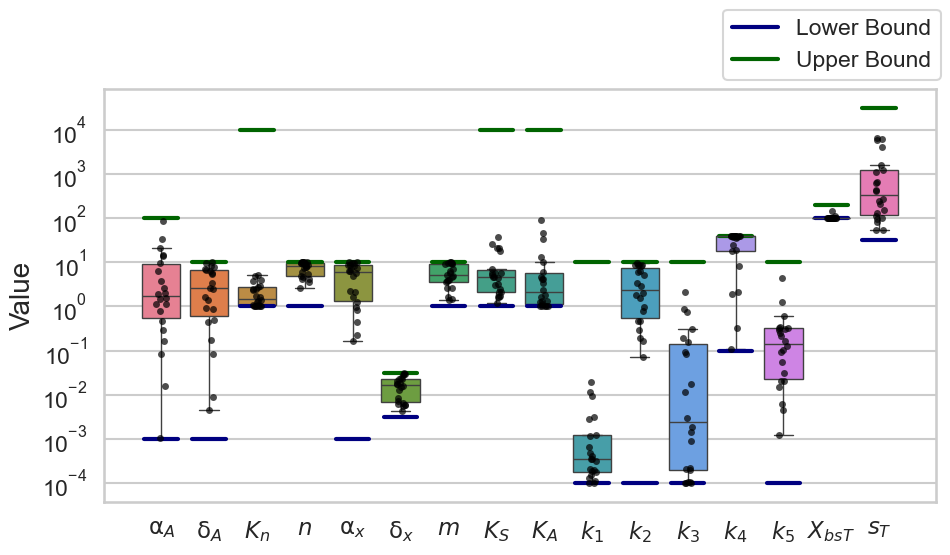

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

a_act_min = -3 #activator synthesis rate from single X chromosome
a_act_max =  2

d_act_min = -3 #degradation rate of free activator
d_act_max = 1

K_n_min = 0 #concentration of bound SPEN at which activator synthesis rate is half max.
K_n_max = 4

n_min = 0 #Hill coefficient for SPEN supressing activator synthesis rate.
n_max = 1

a_x_min = -3 #xist synthesis rate from single X chromosome
a_x_max = 1

d_x_min = -2.5 #degradation rate of Xist
d_x_max = -1.5

m_min = 0  #Hill coefficient for bound SPEN reducing dissociation rate Xist
m_max = 1

K_S_min = 0 #Half max for SPEN inhibiting Xist dissociation
K_S_max = 4

K_a_min = 0 # concentration of activator at which Xist transcription is half max.
K_a_max = 4
    
k1_min = -4 #rate constant for Xist binding to DNA
k1_max = 1

k2_min = -4 #maximum dissociation rate for Xist
k2_max = 1

k3_min = -4 #maximum dissociation rate for Xist
k3_max = 1

k4_min = -1 #dissoication rate for bound SPEN
k4_max = 1.6

k5_min = -4 #association rate for SPEN
k5_max = 1

sT_min = 1.5 #Total SPEN concentration
sT_max = 4.5

XbsT_min = 2
XbsT_max = 2.3

# Set a clean style and context for the plot
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))
curr_df = good_df.drop(columns=['Score'])

# Use a pastel color palette for the boxplot
num_boxes = curr_df.shape[1]
unique_colors = sns.color_palette("husl", num_boxes)
sns.boxplot(data=curr_df, showfliers=False, palette=unique_colors)

# Use a softer gray for the stripplot
sns.stripplot(data=curr_df, color='k', alpha=0.7)

plt.ylabel('Value', fontsize=20)
plt.xlabel('')
plt.yscale('log')

# Calculate boundaries (example provided with np.power)
lower_bounds = np.power(10, [a_act_min, d_act_min, K_n_min, n_min, a_x_min, d_x_min, 
                               m_min, K_S_min, K_a_min, k1_min, k2_min, k3_min,k4_min, 
                               k5_min, XbsT_min, sT_min])
upper_bounds = np.power(10, [a_act_max, d_act_max, K_n_max, n_max, a_x_max, d_x_max, 
                               m_max, K_S_max, K_a_max, k1_max, k2_max, k3_max,k4_max, 
                               k5_max, XbsT_max, sT_max])

# Plot the boundaries with a more subtle style
for i, (low, high) in enumerate(zip(lower_bounds, upper_bounds)):
    plt.plot([i-0.35, i+0.35], [low, low], color='navy', linestyle='-', linewidth=3,
             label='Lower Bound' if i == 0 else "")
    plt.plot([i-0.35, i+0.35], [high, high], color='darkgreen', linestyle='-', linewidth=3,
             label='Upper Bound' if i == 0 else "")
plt.xticks(range(0,16),[r'$\mathrm{\alpha}_{A}$',r'$\mathrm{\delta}_{A}$','$K_n$','$n$',r'$\mathrm{\alpha}_x$',r'$\mathrm{\delta}_x$','$m$','$K_S$','$K_A$',
           '$k_1$','$k_2$','$k_3$','$k_4$','$k_5$','$X_{bsT}$','$s_T$'])

plt.legend(loc='upper left', bbox_to_anchor=(0.73, 1.22))
plt.tight_layout()

plt.savefig(folder+'/EAParams.png', bbox_inches='tight', dpi=300)
plt.savefig(folder+'/EAParams.pdf', bbox_inches='tight', dpi=300)
plt.show()
